## CSV Data Generation, Analysis, and Efficiency Evaluation
In this part of the mini-project, you will develop a series of Python functions to **generate** and **analyze** **CSV data**, and then **evaluate the runtime efficiency** of the functions you have written. This task is divided into three main parts:

1. Data Generation (Part 1) – You will write a function to generate and store data in a CSV file.
2. Data Analysis (Part 2) – You will implement functions to analyze the data from the CSV file.
3. Efficiency Evaluation (Part 3) – You will assess the runtime efficiency of your data analysis functions.

In [2]:
import matplotlib.pyplot as plt
import random
import time
import os

#### Part 1: CSV Data Generation  
You will implement two functions to **generate** a CSV file:  

- **`generateRow`**: Generates a single row of CSV data. This function should randomly generate `colcount` integers, each within the range `[minval, maxval]`.  
- **`generateCSV`**: Calls the `generateRow` function to generate `rowcount` rows of data and then saves the generated data to the file specified by `fname`.  

##### Notes:  
Carefully follow the suggested `random` functions and the exact string formatting specified, as the autograder requires an exact match for both.  

To assist with debugging, several example files have been provided, and a helper function, `compareFiles()`, is available to help you identify any mismatched lines.  

Example files are located in the `example/` directory. Your output files will be saved in the `data/` directory by default, so you can compare them directly.


In [3]:
# INPUT:
# f1, a string containing the file path to the first file being compared
# f2, a string containing the file path to the second file being compared
# OUTPUT:
# A boolean (True) if the files are identical and (False) otherwise.
# It also prints the first line pair which is not identical after whitespace is stripped
def compareFiles(f1, f2):
    with open(f1, 'r') as myf1:
        with open(f2, 'r') as myf2:
            f1_line = myf1.readline().strip()
            f2_line = myf2.readline().strip()
            while f1_line or f2_line:
                if f1_line != f2_line:
                    print("F1: {}".format(f1_line))
                    print("F2: {}".format(f2_line))
                    return False
                f1_line = myf1.readline().strip()
                f2_line = myf2.readline().strip()
    return True

#compareFiles("example1.csv", "example1.csv")

In [4]:
#grade

# generateRow
# Generates a single row of CSV-formatted data as a string.
#
# INPUT:
# - minval (int, optional): The minimum (inclusive) random value to generate. Default is 0.
# - maxval (int, optional): The maximum (inclusive) random value to generate. Default is 99.
# - colcount (int, optional): The number of columns (i.e., the number of values in the row). Default is 2.
# - seed (int, optional): The seed value for Python's random module to ensure reproducibility. Default is None.
#
# OUTPUT:
# - A string representing a single row of CSV data, with values separated by commas.

def generateRow(minval=0, maxval=99, colcount=2, seed=None):
    if seed:
        random.seed(seed)
    
    numbers = []
    
    for i in range(colcount):
        num = random.randint(minval, maxval)
        numbers.append(str(num))
    
    return ",".join(numbers)

In [7]:
# TEST generateRow
print(generateRow()) # This will be a random pair of numbers and should change each run
print(generateRow(colcount=5)) # This will also be random

print(generateRow(seed=5)) #This will always be '79,32'
print(generateRow()) #This will always be '94,45' -- even though the seed isnt being set! Why?
random.seed()
print(generateRow(0, 5)) #These are going back to being random! - Why?
print(generateRow(5, 10))
print(generateRow(0, 99, 5))
print(generateRow(colcount=11, seed=1)) # This will always be '17,72,97,8,32,15,63,97,57,60'

5,39
90,78,75,74,50
79,32
94,45
1,1
8,7
90,43,17,37,4
17,72,97,8,32,15,63,97,57,60,83


In [10]:
#grade

# generateCSV
# Creates a CSV file containing randomly generated numbers with the specified size and value range.
#
# This function generates rows from top to bottom using generateRow(). 
# To match the autograder, DO NOT pass the seed argument to generateRow(). 
# Consider: What happens if you do? (Hint: It may affect randomness across rows.)
#
# INPUT:
# - fname (str, required): The name of the CSV file to be created (must end in .csv).
# - minval (int, optional): The minimum (inclusive) random value to generate. Default is 0.
# - maxval (int, optional): The maximum (inclusive) random value to generate. Default is 99.
# - rowcount (int, optional): The number of rows to generate in the CSV file. Default is 100.
# - colcount (int, optional): The number of columns (values per row). Default is 2.
# - seed (int, optional): The seed value for Python's random module to ensure reproducibility. Default is None.
#
# OUTPUT:
# - None. Instead, a CSV file is created at the specified fname path containing the generated data.

def generateCSV(fname, minval=0, maxval=99, rowcount=100, colcount=2, seed=None):
    if seed:
        random.seed(seed)

    with open(fname, "w") as f:
        for _ in range(rowcount):
            row = generateRow(minval, maxval, colcount)
            f.write(row + "\n")

In [11]:
# TEST generateCSV
# Compare with example/csv/...

generateCSV("./data/csv/example1.csv", seed=5)
generateCSV("./data/csv/example2.csv", 1, 99, rowcount=100000, colcount=100, seed=10)

#### Part 2: Data Analysis  
You will implement two functions to **analyze** the CSV file that you created in Part 1:  

- **`getRowMax`**: Finds the maximum integer value for a given row in a CSV-formatted file.  
- **`countTotalOccurrences`**: Counts the number of exact matches of a given value in a CSV file.  

Unlike in part 1, you have much more freedom of design here -- you can use pandas, numpy, or built-in methods to read in and process your files. **Just be sure the code you are submitting is your own work and no one elses!** The functions you are implementing here are meant to review your Python fundamentals, not your ability to use chatGPT.

In [14]:
#grade

# getRowMax
# Finds the maximum integer value in a specified row of a CSV-formatted file.
#
# INPUT:
# - fname (str, required): The name of the CSV file to read from (must end in .csv).
# - row (int, required): The index of the row to search (0-based, meaning the first row is row 0).
#
# OUTPUT:
# - An integer representing the maximum value in the specified row.
# - Returns -1 if the specified row does not exist.

def getRowMax(fname, row):
    with open(fname, "r") as f:
        for i, line in enumerate(f):
            if i == row:
                values = line.strip().split(",")
                numbers = [int(x) for x in values]
                max_value = max(numbers)
                return max_value
    return -1

In [15]:
# TEST getRowMax
print(getRowMax('example/csv/example1.csv', 5)) # Should be 99
print(getRowMax('example/csv/example1.csv', 0)) # Should be 79
print(getRowMax('example/csv/example2.csv', 5)) # Should be 9
print(getRowMax('example/csv/example2.csv', 999)) # Should be -1

99
79
9
-1


In [16]:
#grade

# countTotalOccurrences
# Counts the total number of times a given integer appears in a CSV file.
#
# INPUT:
# - fname (str, required): The name of the CSV file to search.
# - inVal (int, required): The integer value to search for in the file.
#
# OUTPUT:
# - An integer representing the total number of times inVal appears anywhere in the CSV file.

def countTotalOccurrences(fname, inVal):
    with open(fname, "r") as f:
        
        count = 0
        
        for line in f:
            values = line.strip().split(",")
            numbers = [int(x) for x in values]
            for i in numbers:
                if i == inVal:
                    count += 1
    return count

In [17]:
# TEST countTotalOccurrences
print(countTotalOccurrences('example/csv/example1.csv', 99)) #4
print(countTotalOccurrences('example/csv/example1.csv', 36)) #0

4
0


#### Part 3: Runtime Efficiency Evaluation  

In this part, you will evaluate the runtime efficiency of the `countTotalOccurrences` function from Part 2. You **must** complete Part 2 and pass the autograder before starting this part. Unlike previous parts, this section **will not be autograded** but will be **graded manually**.  

##### **Instructions**  

1. **Generate CSV Files**  
   - Re-run the `generateCSV` function with different values of `rowcount` (e.g., `10, 100, 1000, 5000`).  
   - **Keep the following parameters fixed:**  
     - `minval = 1`  
     - `maxval = 99`  
     - `colcount = 100`  
   - **Ensure that `rowcount` does not exceed 100,000**, as PrairieLearn has limited storage capacity.  

2. **Measure Runtime Performance**  
   - For each experiment (one function run with a different `rowcount` value):  
     - Generate a CSV file using `generateCSV`.  
     - Process the generated CSV file using `countTotalOccurrences`.  
     - Record the function’s runtime and the corresponding `rowcount` value.  

3. **Plot and Submit Results**  
   - Store the recorded runtime values and `rowcount` values in two lists.  
   - Plot the relationship between `rowcount` and runtime.  
   - Download the plot (as a PNG image) to your local computer.  
   - Upload the image to the **Part 3 submission folder** for grading.  


In [64]:
# evaluateRuntime: Evaluates the runtime of the countTotalOccurrences function for different row counts.

# INPUT:
# rowcounts (list of int): A list of rowcount values to test.
# fname (str, optional): The name of the CSV file to be generated and tested. Default is "test_file.csv".
# inVal (int, optional): The integer value to search for in the generated CSV file. Default is 50.

# OUTPUT:
# List of rowcount values used in the experiments.
# Corresponding runtimes (in seconds) for each rowcount value.

def evaluateRuntime(rowcounts, fname="test_file.csv", inVal=50):
    runtimes = []
    
    for rowcount in rowcounts:
        generateCSV(fname, rowcount=rowcount, colcount=100, minval=1, maxval=99)
        
        start = time.time()
        countTotalOccurrences(fname, inVal)
        end = time.time()
        
        runtime = end - start
        runtimes.append(runtime)
    
    return rowcounts, runtimes

In [65]:
# TEST evaluateRuntime
rowcounts = [10000, 30000, 50000, 70000, 90000]
rowcounts_used, runtimes = evaluateRuntime(rowcounts, fname="test_file.csv", inVal=50)

In [66]:
def plotRuntime(rowcounts, runtimes):
    plt.figure(figsize=(10, 5))  # Set figure size
    plt.plot(rowcounts, runtimes, marker="o", linestyle="-", label="Runtime (seconds)")

    plt.xlabel("Number of Rows (rowcount)")
    plt.ylabel("Execution Time (seconds)")
    plt.title("Runtime of countTotalOccurrences")
    plt.legend()

    plt.savefig("runtime_plot_csv.png")

    plt.show()

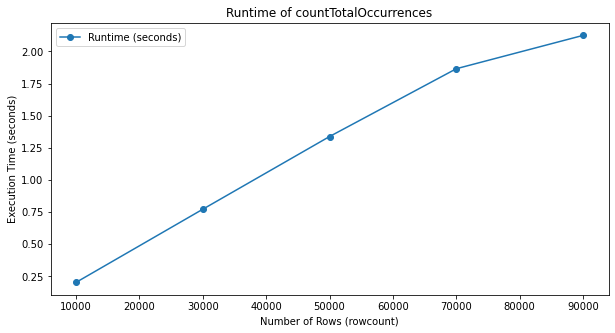

In [67]:
# TEST plotRuntime and SAVE PLOT
plotRuntime(rowcounts, runtimes)